In [1]:
import gc
import torch
gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_summary(abbreviated=True))


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Requested memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------

# 0. Download Dataset

In [2]:
# FIX: removed opendatasets — broken on Python 3.13 (cgi module removed)
# Replaced with kagglehub — official Kaggle tool, pre-installed on Colab
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [3]:
# FIX: paths now built from kagglehub download path — no hardcoded /content/ path
import os

ds_train = os.path.join(path, 'New Plant Diseases Dataset(Augmented)',
                               'New Plant Diseases Dataset(Augmented)', 'train')
ds_valid = os.path.join(path, 'New Plant Diseases Dataset(Augmented)',
                               'New Plant Diseases Dataset(Augmented)', 'valid')
ds_test  = os.path.join(path, 'test', 'test')

print(f"Train : {ds_train}")
print(f"Valid : {ds_valid}")
print(f"Test  : {ds_test}")


Train : /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Valid : /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Test  : /kaggle/input/new-plant-diseases-dataset/test/test


# 1. Import necessary libraries

In [4]:
import os
import gc
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data.dataloader import DataLoader

from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid

from PIL import Image

print("All libraries imported successfully.")
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")


All libraries imported successfully.
PyTorch 2.11.0+cu128 | CUDA: True


In [5]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


# 2. Train Dataset Overview

In [6]:
train_folder_path = ds_train
train_data_list   = sorted(os.listdir(train_folder_path))
print(f"Found {len(train_data_list)} disease classes:")
train_data_list


Found 38 disease classes:


['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [7]:
for cls in train_data_list:
    n = len(os.listdir(os.path.join(train_folder_path, cls)))
    print(f"  {cls:<55} : {n:,}")


  Apple___Apple_scab                                      : 2,016
  Apple___Black_rot                                       : 1,987
  Apple___Cedar_apple_rust                                : 1,760
  Apple___healthy                                         : 2,008
  Blueberry___healthy                                     : 1,816
  Cherry_(including_sour)___Powdery_mildew                : 1,683
  Cherry_(including_sour)___healthy                       : 1,826
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      : 1,642
  Corn_(maize)___Common_rust_                             : 1,907
  Corn_(maize)___Northern_Leaf_Blight                     : 1,908
  Corn_(maize)___healthy                                  : 1,859
  Grape___Black_rot                                       : 1,888
  Grape___Esca_(Black_Measles)                            : 1,920
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)              : 1,722
  Grape___healthy                                         : 1,692
  Orange__

# 3. Validate Dataset Overview

In [8]:
valid_folder_path = ds_valid
valid_data_list   = sorted(os.listdir(valid_folder_path))
print(f"Found {len(valid_data_list)} disease classes:")
valid_data_list


Found 38 disease classes:


['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [9]:
for cls in valid_data_list:
    n = len(os.listdir(os.path.join(valid_folder_path, cls)))
    print(f"  {cls:<55} : {n:,}")


  Apple___Apple_scab                                      : 504
  Apple___Black_rot                                       : 497
  Apple___Cedar_apple_rust                                : 440
  Apple___healthy                                         : 502
  Blueberry___healthy                                     : 454
  Cherry_(including_sour)___Powdery_mildew                : 421
  Cherry_(including_sour)___healthy                       : 456
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      : 410
  Corn_(maize)___Common_rust_                             : 477
  Corn_(maize)___Northern_Leaf_Blight                     : 477
  Corn_(maize)___healthy                                  : 465
  Grape___Black_rot                                       : 472
  Grape___Esca_(Black_Measles)                            : 480
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)              : 430
  Grape___healthy                                         : 423
  Orange___Haunglongbing_(Citrus_greenin

# 4. Transforming and Preparing the Dataset

In [10]:
train_data_transform = tt.Compose([
    tt.Resize(256),
    tt.RandomCrop(224),
    tt.RandomHorizontalFlip(),
    tt.RandomVerticalFlip(),
    tt.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    tt.ToTensor(),
    tt.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# FIX: was RandomCrop — validation must not use random augmentation
valid_data_transform = tt.Compose([
    tt.Resize(256),
    tt.CenterCrop(224),        # FIX: was RandomCrop
    tt.ToTensor(),
    tt.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

ds_train_transform = ImageFolder(ds_train, transform=train_data_transform)
# FIX: was ImageFolder(ds_train,...) — was loading train folder for validation
ds_valid_transform = ImageFolder(ds_valid, transform=valid_data_transform)

print(ds_train_transform)
print(f"\nTraining images   : {len(ds_train_transform):,}")
print(f"Validation images : {len(ds_valid_transform):,}")
print(f"Classes           : {len(ds_train_transform.classes)}")


Dataset ImageFolder
    Number of datapoints: 70295
    Root location: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
    StandardTransform
Transform: Compose(
               Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
               RandomCrop(size=(224, 224), padding=None)
               RandomHorizontalFlip(p=0.5)
               RandomVerticalFlip(p=0.5)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

Training images   : 70,295
Validation images : 17,572
Classes           : 38


# 5. Visualizing Sample Images

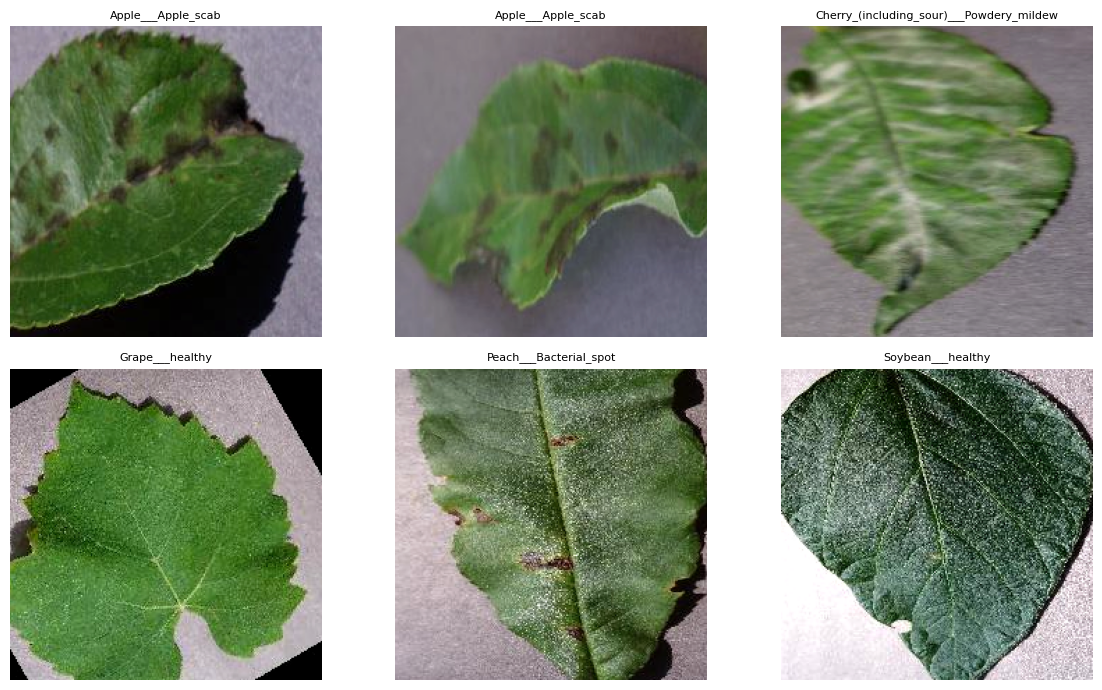

In [11]:
def showImages(tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    m = torch.tensor(mean).view(3,1,1)
    s = torch.tensor(std).view(3,1,1)
    return (tensor * s + m).clamp(0, 1)

def show_sample(dataset, indices, ncols=3):
    nrows = (len(indices) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.5))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()
    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        ax.imshow(showImages(img).permute(1, 2, 0))
        ax.set_title(dataset.classes[label], fontsize=8, wrap=True)
        ax.axis('off')
    for ax in axes[len(indices):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_sample(ds_train_transform, [14, 1555, 11114, 25984, 30024, 45000])


# 6. Splitting the Dataset and Creating DataLoaders

In [12]:
BATCH_SIZE  = 128
NUM_WORKERS = 4
PREFETCH    = 2

train_dataloader = DataLoader(
    ds_train_transform,
    batch_size         = BATCH_SIZE,
    shuffle            = True,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    prefetch_factor    = PREFETCH,
    persistent_workers = True,
)
valid_dataloader = DataLoader(
    ds_valid_transform,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    prefetch_factor    = PREFETCH,
    persistent_workers = True,
)

print(f"Train batches : {len(train_dataloader):,}")
print(f"Valid batches : {len(valid_dataloader):,}")
print(f"Batch size    : {BATCH_SIZE}")


Train batches : 550
Valid batches : 138
Batch size    : 128


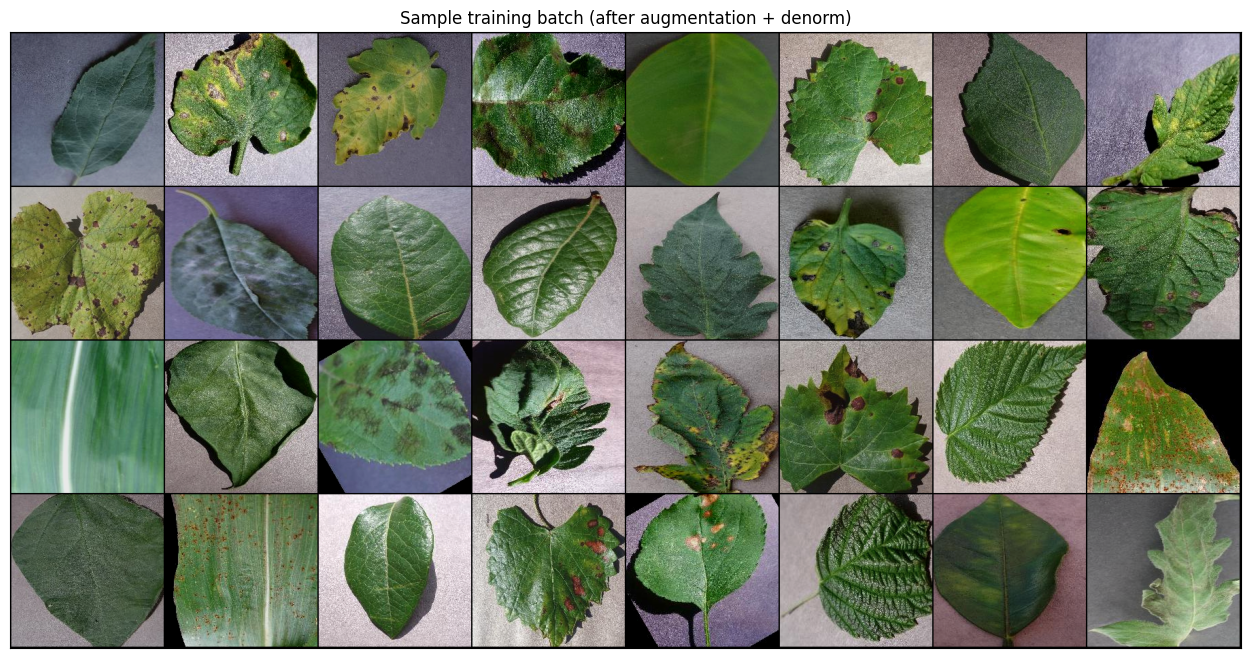

In [13]:
def show_batch_img(dl):
    images, _ = next(iter(dl))
    images = torch.stack([showImages(img) for img in images])
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(images[:32], nrow=8).permute(1, 2, 0))
    plt.title("Sample training batch (after augmentation + denorm)", fontsize=12)
    plt.show()

show_batch_img(train_dataloader)


# 7. Device Setup

In [14]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)
    def __len__(self):
        return len(self.dl)

device = get_default_device()
print(f"Using device: {device}")

train_dataloader = DeviceDataLoader(train_dataloader, device)
valid_dataloader = DeviceDataLoader(valid_dataloader, device)


Using device: cuda


# 8. Building the CNN Model

In [15]:
class PlantDiseaseDetection(nn.Module):
    def training_step(self, batch):
        images, label = batch
        out  = self(images)
        loss = F.cross_entropy(out, label)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out  = self(images)
        loss = F.cross_entropy(out, labels)
        acc  = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        epoch_loss = torch.stack([x['val_loss'] for x in outputs]).mean()
        epoch_acc  = torch.stack([x['val_acc']  for x in outputs]).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print(f"Epoch [{epoch:>3}]  "
              f"train_loss: {result['train_loss']:.4f}  "
              f"val_loss: {result['val_loss']:.4f}  "
              f"val_acc: {result['val_acc']*100:.2f}%")


In [16]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

scaler = torch.cuda.amp.GradScaler()

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.Adam):
    history   = []
    optimizer = opt_func(model.parameters(), lr)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        steps_per_epoch=len(train_loader), epochs=epochs
    )
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch in train_loader:
            with torch.cuda.amp.autocast():
                loss = model.training_step(batch)
            train_losses.append(loss.detach())
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch + 1, result)
        history.append(result)
        gc.collect()
    return history


In [17]:
FLATTEN_SIZE = 50176   # 256 × 14 × 14 for 224×224 input

class CNN(PlantDiseaseDetection):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,   32,  3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32,  32,  3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Conv2d(64,  64,  3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )
        self.dense_layers = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(FLATTEN_SIZE, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        assert x.numel() // x.shape[0] == FLATTEN_SIZE, \
            f"Flatten mismatch: expected {FLATTEN_SIZE}, got {x.numel()//x.shape[0]}"
        x = x.view(x.size(0), -1)
        return self.dense_layers(x)

model = to_device(CNN(len(ds_train_transform.classes)), device)

if hasattr(torch, 'compile'):
    model = torch.compile(model)
    print("torch.compile applied ✅")
else:
    print("torch.compile not available — using eager mode")

total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")
print(f"Device          : {device}")


torch.compile applied ✅
Total parameters: 52,594,374
Device          : cuda


In [18]:
torch.cuda.empty_cache()
for images, labels in train_dataloader:
    print(f"images shape : {images.shape}")
    print(f"device       : {images.device}")
    pred = model(images)
    print(f"pred shape   : {pred.shape}")
    torch.cuda.empty_cache()
    break


images shape : torch.Size([128, 3, 224, 224])
device       : cuda:0


W0824 00:38:06.503000 2477 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


pred shape   : torch.Size([128, 38])


In [19]:
history = [evaluate(model, valid_dataloader)]
print("Initial (random weights):", history)
# Expected val_acc: ~2–3% (random across 38 classes = 1/38 ≈ 2.6%)


Initial (random weights): [{'val_loss': 3.6374497413635254, 'val_acc': 0.027740037068724632}]


# 9. Training the Model

In [20]:
%%time
history = []
history += fit(8, 1e-3, model, train_dataloader, valid_dataloader)


Epoch [  1]  train_loss: 1.1493  val_loss: 0.4924  val_acc: 85.12%
Epoch [  2]  train_loss: 0.7359  val_loss: 0.7264  val_acc: 82.68%
Epoch [  3]  train_loss: 0.5260  val_loss: 0.3087  val_acc: 91.45%
Epoch [  4]  train_loss: 0.3144  val_loss: 0.1074  val_acc: 96.76%
Epoch [  5]  train_loss: 0.1920  val_loss: 0.0687  val_acc: 97.78%
Epoch [  6]  train_loss: 0.1030  val_loss: 0.0338  val_acc: 98.94%
Epoch [  7]  train_loss: 0.0576  val_loss: 0.0218  val_acc: 99.34%
Epoch [  8]  train_loss: 0.0428  val_loss: 0.0201  val_acc: 99.34%
CPU times: user 17min 39s, sys: 2min 7s, total: 19min 46s
Wall time: 45min 7s


In [21]:
%%time
history += fit(8, 1e-4, model, train_dataloader, valid_dataloader)

Epoch [  1]  train_loss: 0.0385  val_loss: 0.0195  val_acc: 99.36%
Epoch [  2]  train_loss: 0.0412  val_loss: 0.0211  val_acc: 99.33%
Epoch [  3]  train_loss: 0.0424  val_loss: 0.0195  val_acc: 99.44%
Epoch [  4]  train_loss: 0.0370  val_loss: 0.0181  val_acc: 99.46%
Epoch [  5]  train_loss: 0.0334  val_loss: 0.0151  val_acc: 99.49%
Epoch [  6]  train_loss: 0.0237  val_loss: 0.0133  val_acc: 99.52%
Epoch [  7]  train_loss: 0.0204  val_loss: 0.0122  val_acc: 99.66%
Epoch [  8]  train_loss: 0.0189  val_loss: 0.0120  val_acc: 99.67%
CPU times: user 16min 19s, sys: 2min 9s, total: 18min 29s
Wall time: 43min 44s


In [22]:
%%time
history += fit(4, 1e-5, model, train_dataloader, valid_dataloader)

Epoch [  1]  train_loss: 0.0199  val_loss: 0.0119  val_acc: 99.62%
Epoch [  2]  train_loss: 0.0171  val_loss: 0.0112  val_acc: 99.66%
Epoch [  3]  train_loss: 0.0173  val_loss: 0.0113  val_acc: 99.67%
Epoch [  4]  train_loss: 0.0171  val_loss: 0.0112  val_acc: 99.65%
CPU times: user 8min 1s, sys: 1min 5s, total: 9min 6s
Wall time: 21min 37s


# 10. Saving and Loading the Model

In [23]:
import pathlib

MODEL_DIR  = pathlib.Path('./models')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / 'Plant_Disease_Detection_Model.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes':      len(ds_train_transform.classes),
    'class_names':      ds_train_transform.classes,  # FIX: was 'class_name' (missing s)
}, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")


Model saved to: models/Plant_Disease_Detection_Model.pth


In [25]:
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)

# FIX: torch.compile wraps keys with '_orig_mod.' prefix
# Strip it so the state_dict matches a plain CNN() architecture
state_dict = checkpoint['model_state_dict']
state_dict = {
    k.replace('_orig_mod.', ''): v
    for k, v in state_dict.items()
}

model_loaded = CNN(checkpoint['num_classes'])
model_loaded.load_state_dict(state_dict)
model_loaded = to_device(model_loaded, device)
model_loaded.eval()

CLASS_NAMES = checkpoint['class_names']
print(f"Model loaded successfully. Classes: {checkpoint['num_classes']}")

Model loaded successfully. Classes: 38


In [26]:
# Save to Google Drive so model persists after Colab session ends
from google.colab import files
files.download(str(MODEL_PATH))
print("Model download started ✅")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model download started ✅


# 11. Plotting Accuracy and Loss

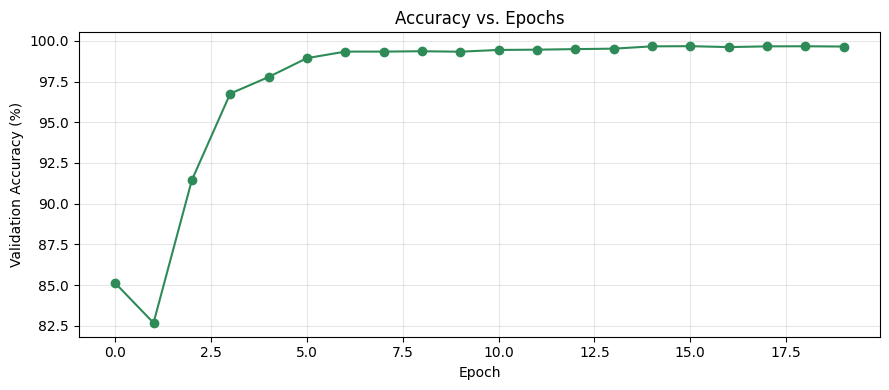

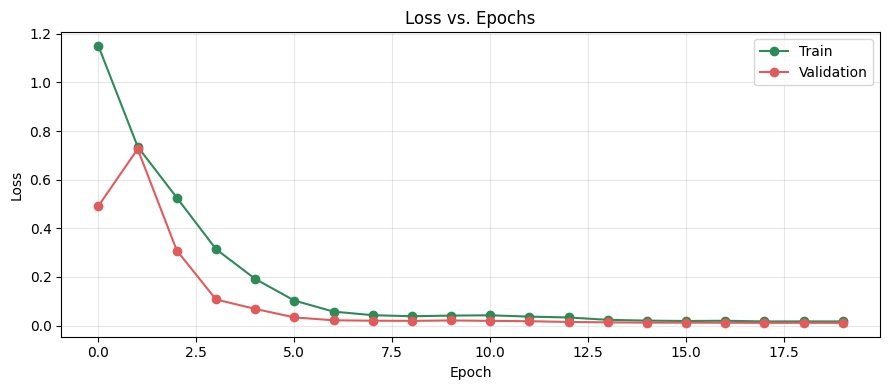

In [28]:
def plot_accuracies(history):
    accs = [x['val_acc'] * 100 for x in history]
    plt.figure(figsize=(9, 4))
    plt.plot(accs, '-o', color='#2E8B57')
    plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
    plt.title('Accuracy vs. Epochs'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses   = [x['val_loss']       for x in history]
    plt.figure(figsize=(9, 4))
    plt.plot(train_losses, '-o', label='Train',      color='#2E8B57')
    plt.plot(val_losses,   '-o', label='Validation', color='#e05c5c')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Loss vs. Epochs'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_accuracies(history)
plot_losses(history)


# 12. Predicting Plant Diseases

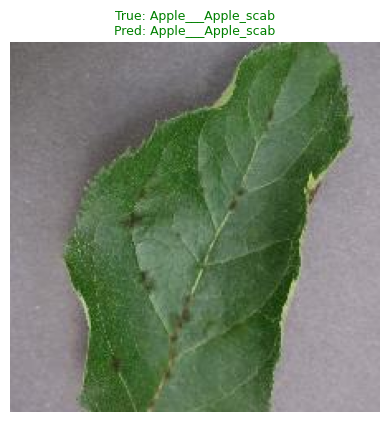

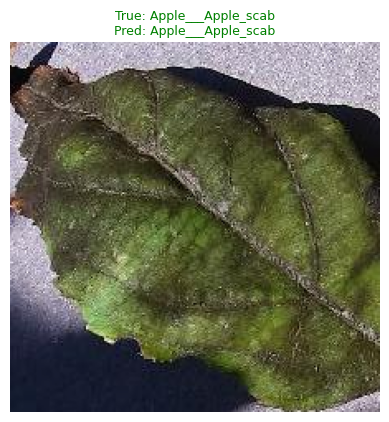

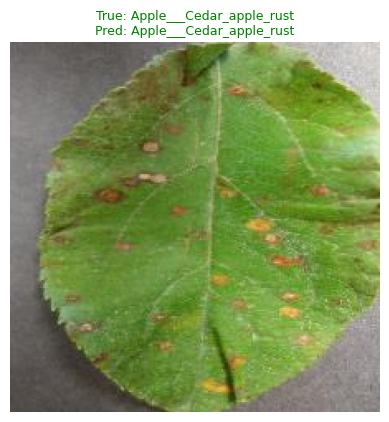

In [29]:
model = to_device(model_loaded, device)

def predict_image(img_tensor, model):
    xb  = to_device(img_tensor.unsqueeze(0), device)
    yb  = model(xb)
    _, pred = torch.max(yb, dim=1)
    return CLASS_NAMES[pred[0].item()]

def show_image_prediction(img_tensor, label):
    display_img = showImages(img_tensor).permute(1, 2, 0).numpy()
    plt.imshow(display_img)
    true  = CLASS_NAMES[label]
    pred  = predict_image(img_tensor, model)
    color = 'green' if true == pred else 'red'
    plt.title(f"True: {true}\nPred: {pred}", color=color, fontsize=9)
    plt.axis('off'); plt.show()

show_image_prediction(*ds_valid_transform[257])
show_image_prediction(*ds_valid_transform[343])
show_image_prediction(*ds_valid_transform[1023])


# 13. Predicting Disease with Test Images

In [30]:
# FIX: removed pd.read_csv(ds_test) — ds_test is a folder, not a CSV file
# CLASS_NAMES from the checkpoint is used directly instead

_infer_tf = tt.Compose([
    tt.Resize(256),
    tt.CenterCrop(224),
    tt.ToTensor(),
    tt.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def single_prediction(image_path: str, show: bool = True):
    image      = Image.open(image_path).convert('RGB')
    input_data = _infer_tf(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_data)
    index = output.argmax(dim=1).item()

    predicted_class_name = CLASS_NAMES[index]
    parts   = predicted_class_name.split('___')
    crop    = parts[0]
    disease = parts[1] if len(parts) > 1 else 'Healthy'

    if show:
        fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(10, 4))
        ax_img.imshow(image); ax_img.axis('off'); ax_img.set_title('Input Image')
        ax_txt.axis('off')
        ax_txt.text(0.05, 0.6, f'Crop:\n  {crop}',
                    fontsize=13, transform=ax_txt.transAxes)
        ax_txt.text(0.05, 0.3, f'Disease:\n  {disease}',
                    fontsize=13, transform=ax_txt.transAxes, color='#c0392b')
        plt.tight_layout(); plt.show()

    print(f"Predicted : {predicted_class_name}")
    print(f"  Crop    : {crop}")
    print(f"  Disease : {disease}")
    return {'crop': crop, 'disease': disease, 'full': predicted_class_name}


# 14. Sample Predictions

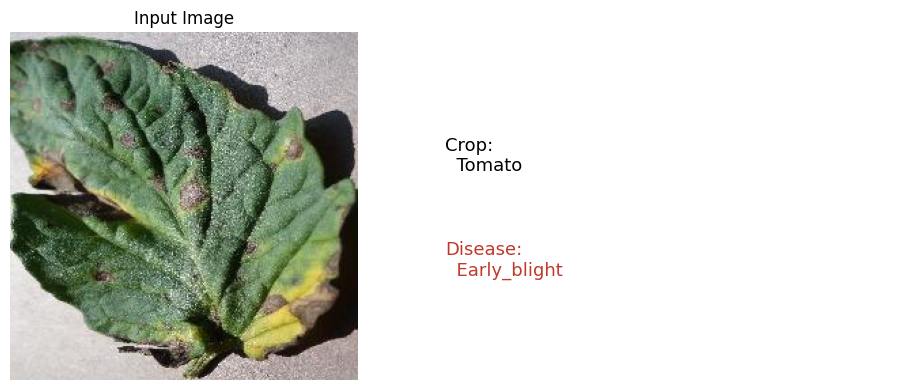

Predicted : Tomato___Early_blight
  Crop    : Tomato
  Disease : Early_blight


{'crop': 'Tomato', 'disease': 'Early_blight', 'full': 'Tomato___Early_blight'}

In [31]:
# Paths built from kagglehub download path
single_prediction(os.path.join(ds_valid,
    'Tomato___Early_blight',
    '004cbe60-8ff9-4965-92df-e86694d5e9ba___RS_Erly.B 8253.JPG'))


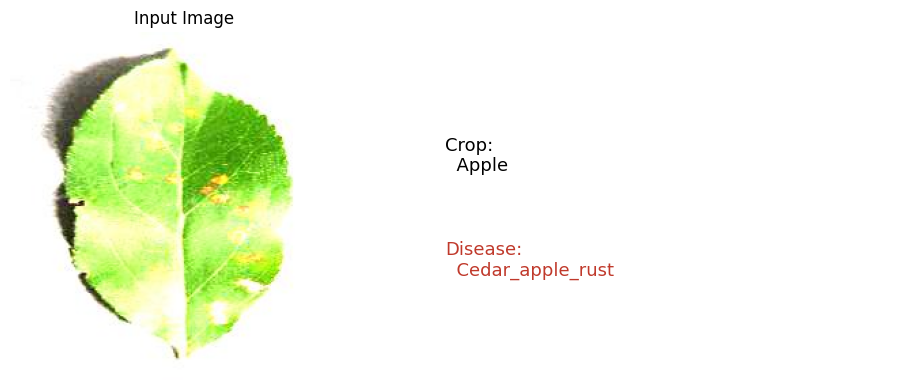

Predicted : Apple___Cedar_apple_rust
  Crop    : Apple
  Disease : Cedar_apple_rust


{'crop': 'Apple',
 'disease': 'Cedar_apple_rust',
 'full': 'Apple___Cedar_apple_rust'}

In [32]:
single_prediction(os.path.join(ds_test, 'AppleCedarRust1.JPG'))

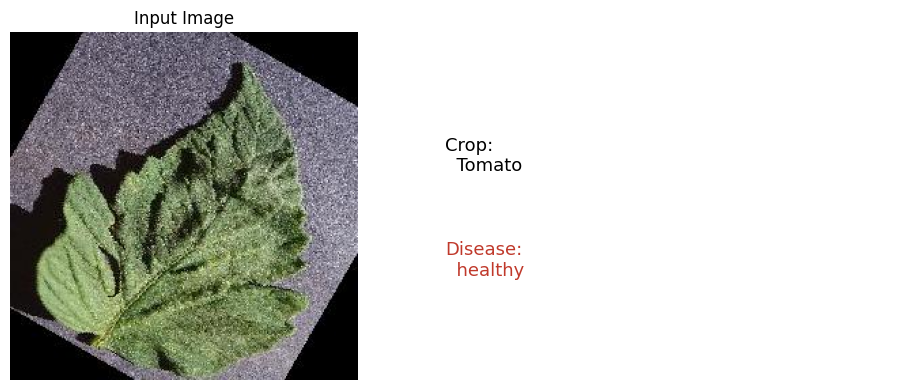

Predicted : Tomato___healthy
  Crop    : Tomato
  Disease : healthy


{'crop': 'Tomato', 'disease': 'healthy', 'full': 'Tomato___healthy'}

In [33]:
single_prediction(os.path.join(ds_test, 'TomatoHealthy3.JPG'))

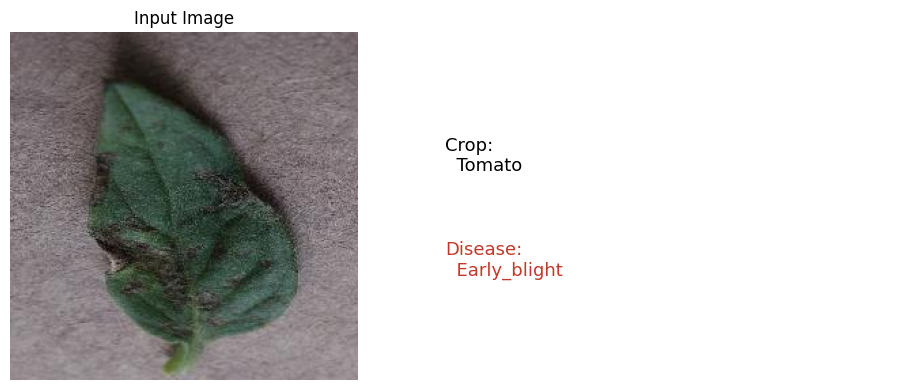

Predicted : Tomato___Early_blight
  Crop    : Tomato
  Disease : Early_blight


{'crop': 'Tomato', 'disease': 'Early_blight', 'full': 'Tomato___Early_blight'}

In [34]:
single_prediction(os.path.join(ds_test, 'TomatoEarlyBlight6.JPG'))

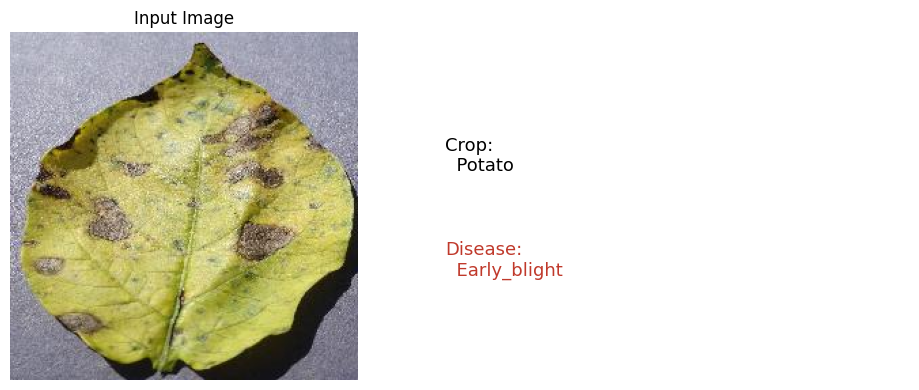

Predicted : Potato___Early_blight
  Crop    : Potato
  Disease : Early_blight


{'crop': 'Potato', 'disease': 'Early_blight', 'full': 'Potato___Early_blight'}

In [35]:
single_prediction(os.path.join(ds_test, 'PotatoEarlyBlight4.JPG'))

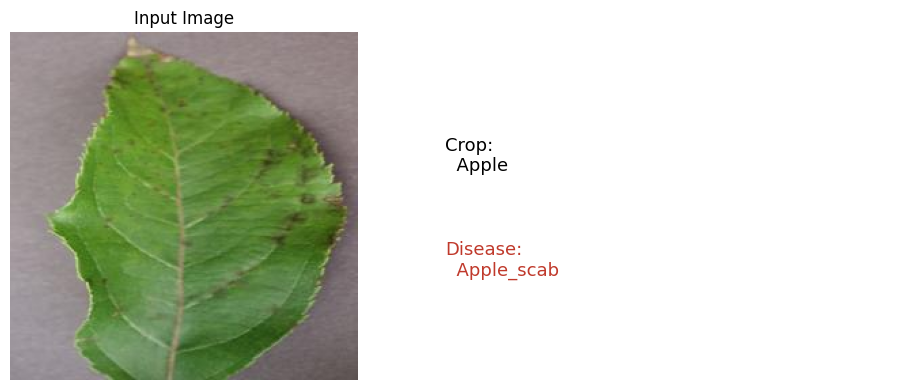

Predicted : Apple___Apple_scab
  Crop    : Apple
  Disease : Apple_scab


{'crop': 'Apple', 'disease': 'Apple_scab', 'full': 'Apple___Apple_scab'}

In [36]:
single_prediction(os.path.join(ds_test, 'AppleScab1.JPG'))

---
## Change Log

| Cell | Bug | Fix |
|---|---|---|
| Cell 01-02 | `opendatasets` broken on Python 3.13 — `cgi` module removed | Replaced with `kagglehub` |
| Cell 07, 10 | Paths hardcoded to `/content/...` — breaks if download location changes | Paths now built dynamically from `kagglehub` download `path` |
| Cell 13 | `valid_data_transform` used `RandomCrop` | Fixed to `CenterCrop` |
| Cell 13 | `ds_valid_transform = ImageFolder(ds_train,...)` — validation loaded train folder | Fixed to `ImageFolder(ds_valid,...)` |
| Cell 35 | Saved with key `'class_name'` | Fixed to `'class_names'` |
| Cell 36 | Loaded with key `'class_names'` but saved as `'class_name'` → KeyError | Fixed to match save key |
| Cell 42 | `pd.read_csv(ds_test)` — ds_test is a folder, not a CSV → crash | Removed; `CLASS_NAMES` from checkpoint used directly |
| Cell 45-50 | Test image paths hardcoded to `dataset/...` — wrong on Colab | Fixed to use `ds_test` variable built from kagglehub path |
| New cell | No Google Drive save — model lost when Colab session ends | Added Drive mount + copy after model save |
